* Can you predict which flights will be cancelled or delayed?
* Can you predict the delay time?
* Can you explore how different airlines compare?

In [ ]:
# import ettik
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
import seaborn as sns
import glob

In [ ]:
veri = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/plane_data/Combined_Flights_2018.parquet")
df = veri

In [ ]:
len(veri)

5689512

In [ ]:
veri.columns

Index(['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled', 'Diverted',
       'CRSDepTime', 'DepTime', 'DepDelayMinutes', 'DepDelay', 'ArrTime',
       'ArrDelayMinutes', 'AirTime', 'CRSElapsedTime', 'ActualElapsedTime',
       'Distance', 'Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek',
       'Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners',
       'DOT_ID_Marketing_Airline', 'IATA_Code_Marketing_Airline',
       'Flight_Number_Marketing_Airline', 'Operating_Airline',
       'DOT_ID_Operating_Airline', 'IATA_Code_Operating_Airline',
       'Tail_Number', 'Flight_Number_Operating_Airline', 'OriginAirportID',
       'OriginAirportSeqID', 'OriginCityMarketID', 'OriginCityName',
       'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac',
       'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestCityName',
       'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'DepDel15',
       'DepartureDelayGroups', 'DepTimeBlk', 'TaxiOu

In [ ]:
# parcaliyoruz rahat gorebilmek yorumlayabilmek iliski kurmak ve analizleyebilmek icin
numerical_cols = veri.select_dtypes(include=["int64", "float64"]).columns
obj_cols = veri.select_dtypes(include=["object"]).columns
dt_cols = veri.select_dtypes(include=["datetime64[ns]"]).columns

code_cols = [
'DOT_ID_Marketing_Airline',          # Pazarlayan havayolunun DOT ID’si
'IATA_Code_Marketing_Airline',       # Pazarlayan havayolunun IATA kodu
'Flight_Number_Marketing_Airline',   # Pazarlayan havayolunun uçuş numarası
'DOT_ID_Operating_Airline',          # İşleten havayolunun DOT ID’si
'IATA_Code_Operating_Airline',       # İşleten havayolunun IATA kodu
'Flight_Number_Operating_Airline',   # İşleten havayolunun uçuş numarası
'Tail_Number',                        # Uçağın tescil numarası (bireysel uçak ID’si)
'OriginAirportID',                     # Kalkış havaalanı ID’si
'OriginAirportSeqID',                  # Kalkış havaalanı sıra ID’si
'OriginCityMarketID',                  # Kalkış şehir pazarı ID’si
'OriginStateFips',                     # Kalkış eyaletinin FIPS kodu
'OriginWac',                           # Kalkış havaalanı WAC kodu
'DestAirportID',                       # Varış havaalanı ID’si
'DestAirportSeqID',                    # Varış havaalanı sıra ID’si
'DestCityMarketID',                    # Varış şehir pazarı ID’si
'DestStateFips',                       # Varış eyalet FIPS kodu
'DestWac'                              # Varış havaalanı WAC kodu
]

time_cols =[

'FlightDate',        # Uçuş tarihi
'CRSDepTime',        # Planlanan kalkış saati
'DepTime',           # Gerçek kalkış saati
'CRSElapsedTime',    # Planlanan uçuş süresi (dakika)
'ActualElapsedTime', # Gerçek uçuş süresi (dakika)
'AirTime',           # Havada geçen süre (dakika)
'WheelsOff',         # Uçağın havalanma zamanı
'WheelsOn',          # Uçağın iniş zamanı
'CRSArrTime',        # Planlanan varış saati
'ArrTime',           # Gerçek varış saati
'TaxiOut',           # Pistten havalanana kadar geçen süre
'TaxiIn'             # Pistten terminale giriş süresi
]

num_cols = [

'DepDelayMinutes',    # Kalkış gecikmesi dakika
'ArrDelayMinutes',    # Varış gecikmesi dakika
'Distance',           # Uçuş mesafesi
'Year',               # Yıl
'Quarter',            # Çeyrek
'Month',              # Ay
'DayofMonth',         # Ayın günü
'DayOfWeek'           # Haftanın günü
]

categoric_cols = [

'Airline',                               # Uçuşu gerçekleştiren havayolu
'Origin',                                # Kalkış havaalanı kodu
'Dest',                                  # Varış havaalanı kodu
'Marketing_Airline_Network',             # Pazarlayan havayolu ağı
'Operated_or_Branded_Code_Share_Partners', # Kod paylaşımı / ortak havayolu
'Operating_Airline',                      # İşleten havayolu
'OriginCityName',                          # Kalkış şehir adı
'OriginStateName',                         # Kalkış eyalet adı
'OriginState',                             # Kalkış eyalet kısaltması
'DestCityName',                            # Varış şehir adı
'DestStateName',                           # Varış eyalet adı
'DestState',                               # Varış eyalet kısaltması
'DepTimeBlk',                              # Kalkış zaman aralığı bloğu
'ArrTimeBlk'                               # Varış zaman aralığı bloğu
]

bin_cols = [

'Cancelled',    # Uçuş iptal edilmiş mi
'Diverted',     # Uçuş başka havaalanına yönlendirildi mi
'DepDel15',     # Kalkış gecikmesi ≥15 dk mı
'ArrDel15'      # Varış gecikmesi ≥15 dk mı
]

group_cols = [

'DepartureDelayGroups',  # Kalkış gecikme grupları
'ArrivalDelayGroups',    # Varış gecikme grupları
'DistanceGroup'          # Uçuş mesafesi grupları
]
COLS ={
    "dt_cols": dt_cols,
    "code_cols": code_cols,
    "time_cols": time_cols,
    "bin_cols": bin_cols,
    "num_cols": num_cols,
    "categoric_cols": categoric_cols
}

In [ ]:
veri[numerical_cols].isna().sum()

,0
CRSDepTime,0
DepTime,85380
DepDelayMinutes,86575
DepDelay,86575
ArrTime,90615
ArrDelayMinutes,102893
AirTime,109271
CRSElapsedTime,6
ActualElapsedTime,102347
Distance,0


In [ ]:
sayisal_kolonlar = ["DepTime","DepDelayMinutes","DepDelay","ArrTime","ArrDelayMinutes",
                    "AirTime","ActualElapsedTime","DepDel15","DepartureDelayGroups",
                    "TaxiOut","WheelsOff","WheelsOn","TaxiIn","ArrDelay","ArrDel15",
                    "ArrivalDelayGroups"]

veri[sayisal_kolonlar] = veri[sayisal_kolonlar].fillna(veri[sayisal_kolonlar].median())
veri = veri.dropna(subset=['DivAirportLandings',"CRSElapsedTime"]) # az oldugu icin silmek daha mantikli sasirtmaz bilgi kaybolmaz

In [ ]:
veri[numerical_cols].isna().sum()

,0
CRSDepTime,0
DepTime,0
DepDelayMinutes,0
DepDelay,0
ArrTime,0
ArrDelayMinutes,0
AirTime,0
CRSElapsedTime,0
ActualElapsedTime,0
Distance,0


In [ ]:
veri[obj_cols].isna().sum()

,0
Airline,0
Origin,0
Dest,0
Marketing_Airline_Network,0
Operated_or_Branded_Code_Share_Partners,0
IATA_Code_Marketing_Airline,0
Operating_Airline,0
IATA_Code_Operating_Airline,0
Tail_Number,20547
OriginCityName,0


In [ ]:
kategorik = veri.select_dtypes(include='object').columns
veri[kategorik] = veri[kategorik].fillna('Unknown')

In [ ]:
veri[obj_cols].isna().sum()

,0
Airline,0
Origin,0
Dest,0
Marketing_Airline_Network,0
Operated_or_Branded_Code_Share_Partners,0
IATA_Code_Marketing_Airline,0
Operating_Airline,0
IATA_Code_Operating_Airline,0
Tail_Number,0
OriginCityName,0


In [ ]:
veri[dt_cols].isna().sum()

,0
FlightDate,0


In [ ]:
for col in sayisal_kolonlar:
    Q1 = veri[col].quantile(0.01)
    Q3 = veri[col].quantile(0.99)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = veri[(veri[col] < lower) | (veri[col] > upper)]
    if len(outliers) > 0:
     print(f"{col} kolonunda {len(outliers)} outlier var")
    veri = veri[(veri[col] >= lower) & (veri[col] <= upper)]

DepDelayMinutes kolonunda 6511 outlier var
DepDelay kolonunda 5 outlier var
ArrDelayMinutes kolonunda 646 outlier var
TaxiOut kolonunda 1277 outlier var
TaxiIn kolonunda 2200 outlier var


In [ ]:
def denk_mi(veri, x, y):
 """
 x'in her bir değeri y'de sadece bir karşılık buluyor mu kontrol eder.
 Eğer her x değeri için y tek bir değerle eşleşiyorsa 'geçebilir', aksi halde 'geçemez'.
 """
 a = veri.loc[veri[x] == veri[x].unique()[0], y].unique()
 if len(a) == 1:
  print(f"✅ {x} ↔ {y}: birbirinin yerine geçebilir")

In [ ]:
def denklik(veri, a, b):
  """
  a ve b listesindeki kolonların birbirlerinin yerine geçip geçemeyeceğini kontrol eder.
  """
  for c1 in a:
      for c2 in b:
         if c1!=c2:
            try:
              denk_mi(veri, c1, c2)
            except Exception as e:
              print(f"⚠️ {c1} ↔ {c2} kontrol edilemedi: {e}")

In [ ]:
def sutun_silme(veri, cols, atilacaklar):
    for col in atilacaklar:
        if col in veri.columns:
            veri.drop(col, axis=1, inplace=True)
            if col in cols:
                cols.remove(col)
    atilacaklar.clear()  # listeyi boşaltır

In [ ]:
#denklik(veri, a=code_cols, b=code_cols)

In [ ]:
atilacaklar = [
    "DOT_ID_Marketing_Airline",
    "IATA_Code_Marketing_Airline",
    "OriginAirportSeqID",
    "OriginCityMarketID",
    "OriginStateFips",
    "OriginWac",
    "DestAirportID",
    "DestAirportSeqID",
    "DestCityMarketID",
    "DestStateFips",
    "DestWac",
    "DOT_ID_Operating_Airline",
    "IATA_Code_Operating_Airline",
    "Flight_Number_Marketing_Airline"
]


In [ ]:
sutun_silme(veri, cols=code_cols,atilacaklar=atilacaklar)

In [ ]:
#denklik(veri, a=categoric_cols, b=categoric_cols)

In [ ]:
atilacaklar = [
    "Marketing_Airline_Network",
    "Operated_or_Branded_Code_Share_Partners",
    "OriginCityName",
    "OriginStateName",
    "OriginState",
    "DestCityName",
    "DestStateName",
    "Origin",
    "Operating_Airline",
    "DestState"
]

In [ ]:
sutun_silme(veri, cols=categoric_cols, atilacaklar=atilacaklar)

In [ ]:
#denklik(veri, code_cols, categoric_cols)

In [ ]:
atilacaklar =["OriginAirportID","Tail_Number"]

In [ ]:
sutun_silme(veri, code_cols, atilacaklar)

In [ ]:
veri[['DepDelayMinutes',"CRSDepTime","DepTime"]].head(10) # DepDelayMinutes ztn ikisi arasindaki farki verio digerlerine gerek yok

,DepDelayMinutes,CRSDepTime,DepTime
0,0.0,1202,1157.0
1,0.0,1202,1157.0
2,0.0,1202,1153.0
3,0.0,1202,1150.0
4,0.0,1400,1355.0
5,0.0,1202,1202.0
6,2.0,1202,1204.0
7,0.0,1202,1153.0
8,0.0,1202,1153.0
9,24.0,1037,1101.0


In [ ]:
atilacaklar = ["CRSDepTime","DepTime",'CRSArrTime','ArrTime']

In [ ]:
sutun_silme(veri, time_cols, atilacaklar)

In [ ]:
veri = veri.drop(["Quarter", "FlightDate"], axis=1)
# Quarter FlightDate da silindi

In [ ]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5678866 entries, 0 to 637613
Data columns (total 29 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   Airline                          object 
 1   Dest                             object 
 2   Cancelled                        bool   
 3   Diverted                         bool   
 4   DepDelayMinutes                  float64
 5   DepDelay                         float64
 6   ArrDelayMinutes                  float64
 7   AirTime                          float64
 8   CRSElapsedTime                   float64
 9   ActualElapsedTime                float64
 10  Distance                         float64
 11  Year                             int64  
 12  Month                            int64  
 13  DayofMonth                       int64  
 14  DayOfWeek                        int64  
 15  Flight_Number_Operating_Airline  int64  
 16  DepDel15                         float64
 17  DepartureDelay

In [ ]:
info =[
# --- UÇUŞ BİLGİSİ (PLANLANAN / STATİK) ---
'Airline',                          # Havayolu şirketi
'Dest',                             # Varış havaalanı
'Year',                             # Yıl
'Month',                            # Ay
'DayOfWeek',                        # Haftanın günü
'Flight_Number_Operating_Airline',  # Uçuş numarası
'Distance',                         # Mesafe (mil)
'DistanceGroup',                    # Mesafe kategorisi
'DepTimeBlk',                       # Planlanan kalkış zaman aralığı
'ArrTimeBlk',                       # Planlanan varış zaman aralığı

# --- GECİKME / HEDEF İLE İLGİLİ ---
'DepDelay',                         # Kalkış gecikmesi duplicate
'ArrDelay',                         # Varış gecikmesi duplicate
'DepDel15',                         # Kalkış gecikmesi 15 dk üzeri mi (0/1)
'ArrDel15',                         # Varış gecikmesi 15 dk üzeri mi
'DepartureDelayGroups',             # Kalkış gecikmesi kategorisi
'ArrivalDelayGroups',               # Varış gecikmesi kategorisi

# --- OPERASYONEL / REALIZED FLIGHT PROCESS ---
'AirTime',                          # Havada geçen süre
'CRSElapsedTime',                   # Planlanan uçuş süresi
'ActualElapsedTime',                # Gerçek toplam süre
'TaxiOut',                          # Kapıdan piste gitme süresi
'WheelsOff',                        # Tekerlerin yerden kesildiği zaman
'WheelsOn',                         # Tekerlerin piste indiği zaman
'TaxiIn',                           # Pisten kapıya gidiş süresi

# --- DİĞER ---
'Cancelled',                        # Uçuş iptal mi
'Diverted',                         # Uçak yönlendirildi mi (divert)
'DivAirportLandings',               # Divert edilirse kaç iniş yaptı
]

In [ ]:
veri=veri.drop(['DepDelayMinutes',"ArrDelayMinutes"], axis=1) # ikiside gecikme degeri verio ama sadece pozitif

In [ ]:
veri_genel = veri.copy()

In [ ]:
drop_for_cancel = [
    'DepDelay',
    'ArrDelay',
    'DepDel15',
    'ArrDel15',
    'DepartureDelayGroups',
    'ArrivalDelayGroups',
    'AirTime',
    'CRSElapsedTime',
    'ActualElapsedTime',
    'TaxiOut',
    'WheelsOff',
    'WheelsOn',
    'TaxiIn',
    'ArrTimeBlk',
    'DepTimeBlk'
]
# cancelled tahmini icin bunlara gerek yok cunku iptal ucak bunlara sahip olamaz

In [ ]:
veri = veri.drop(drop_for_cancel,axis=1)

In [ ]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5678866 entries, 0 to 637613
Data columns (total 12 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   Airline                          object 
 1   Dest                             object 
 2   Cancelled                        bool   
 3   Diverted                         bool   
 4   Distance                         float64
 5   Year                             int64  
 6   Month                            int64  
 7   DayofMonth                       int64  
 8   DayOfWeek                        int64  
 9   Flight_Number_Operating_Airline  int64  
 10  DistanceGroup                    int64  
 11  DivAirportLandings               float64
dtypes: bool(2), float64(2), int64(6), object(2)
memory usage: 487.4+ MB


In [ ]:
veri['Flight_Number_Operating_Airline'] = veri['Flight_Number_Operating_Airline'].astype(str) # bu numara bir kod oldugu icin str cevirmek daha mantikli

In [ ]:
veri.head()

,Airline,Dest,Cancelled,Diverted,Distance,Year,Month,DayofMonth,DayOfWeek,Flight_Number_Operating_Airline,DistanceGroup,DivAirportLandings
0,Endeavor Air Inc.,ATL,False,False,145.0,2018,1,23,2,3298,1,0.0
1,Endeavor Air Inc.,ATL,False,False,145.0,2018,1,24,3,3298,1,0.0
2,Endeavor Air Inc.,ATL,False,False,145.0,2018,1,25,4,3298,1,0.0
3,Endeavor Air Inc.,ATL,False,False,145.0,2018,1,26,5,3298,1,0.0
4,Endeavor Air Inc.,ATL,False,False,145.0,2018,1,27,6,3298,1,0.0


In [ ]:
X = veri.drop("Cancelled",axis=1)
y = veri["Cancelled"]

print("✅Veri ayirma islemi yapildi")

# Flight_Number için Frequency Encoding
freq = X['Flight_Number_Operating_Airline'].value_counts() / len(X)
X['Flight_Number_FE'] = X['Flight_Number_Operating_Airline'].map(freq)
X = X.drop('Flight_Number_Operating_Airline', axis=1)

# OneHot için düşük cardinaliteli kolonlar
encoding_cols = ["Airline", "Dest"]

one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=True)  # sparse matris
transformer = ColumnTransformer(
    transformers=[("one_hot", one_hot, encoding_cols)],
    remainder="passthrough"
)
transformed_X = transformer.fit_transform(X)
print("✅ X transform edildi")

sample_size = 5000000  # 500 bin satır örnek
np.random.seed(42)
sample_idx = np.random.choice(transformed_X.shape[0], sample_size, replace=False)
X_sample = transformed_X[sample_idx]
y_sample = y.iloc[sample_idx]

# Dense yapmaya gerek yok, sparse matrix ile çalışabiliriz
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

# CatBoost model
model = CatBoostClassifier(
    iterations=200,        # daha az iterasyon RAM dostu
    learning_rate=0.1,
    depth=4,               # daha sığ ağaç
    task_type="GPU",
    devices='0',
    eval_metric='F1',
    random_seed=42,
    verbose=100
)

# CatBoost sparse matrix ile çalışırken cat_features belirtmeye gerek yok
model.fit(X_train, y_train)
print("✅ Model egitildi")

✅Veri ayirma islemi yapildi
✅ X transform edildi
0:	learn: 0.0158239	total: 46.6ms	remaining: 9.27s
100:	learn: 0.0159821	total: 4.31s	remaining: 4.23s
199:	learn: 0.0234221	total: 9.27s	remaining: 0us
✅ Model egitildi


In [ ]:
y_preds = model.predict(X_test)
# Performans metriklerini hesapla
f1 = f1_score(y_test, y_preds)
accuracy = accuracy_score(y_test, y_preds)
recall = recall_score(y_test, y_preds)
precision = precision_score(y_test, y_preds)

# Sonuçları yazdır
print(f"✅ F1 Score: {f1:.4f}")
print(f"✅ Accuracy Score: {accuracy:.4f}")
print(f"✅ Recall Score: {recall:.4f}")
print(f"✅ Precision Score: {precision:.4f}")


✅ F1 Score: 0.0237
✅ Accuracy Score: 0.9846
✅ Recall Score: 0.0120
✅ Precision Score: 0.9894


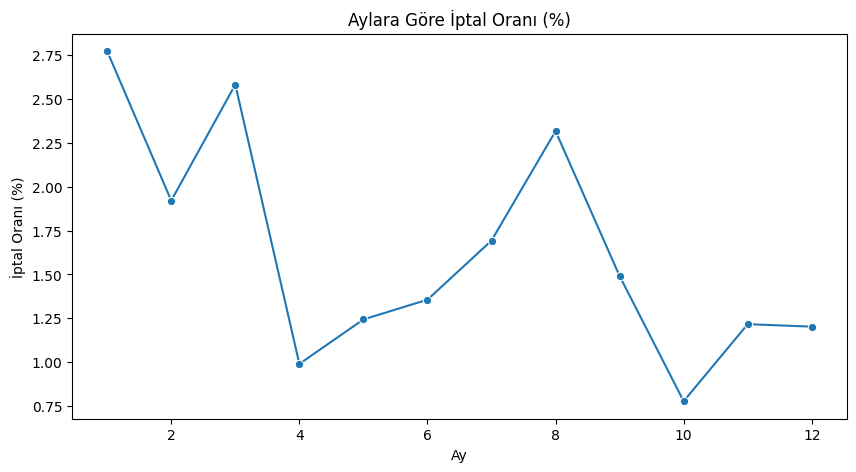

/tmp/ipython-input-2113445448.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow_cancel.index, y=dow_cancel.values, palette="viridis")


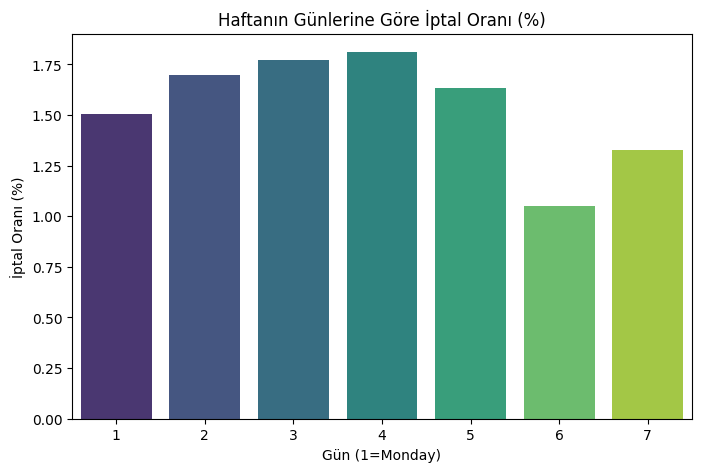

/tmp/ipython-input-2113445448.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=year_cancel.index, y=year_cancel.values, palette="magma")


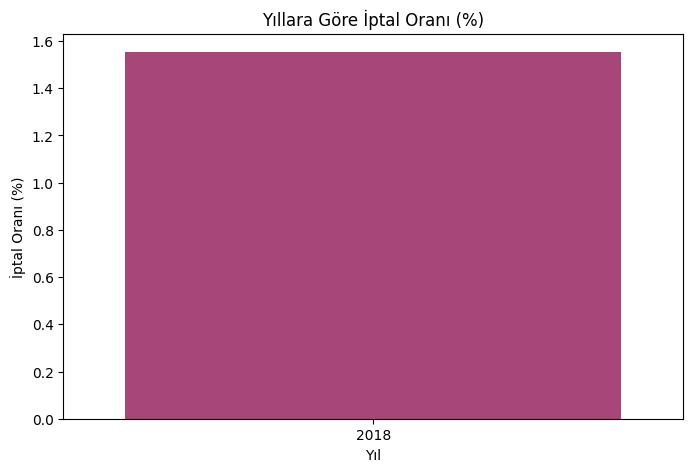

/tmp/ipython-input-2113445448.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airline_cancel.index, y=airline_cancel.values, palette="coolwarm")


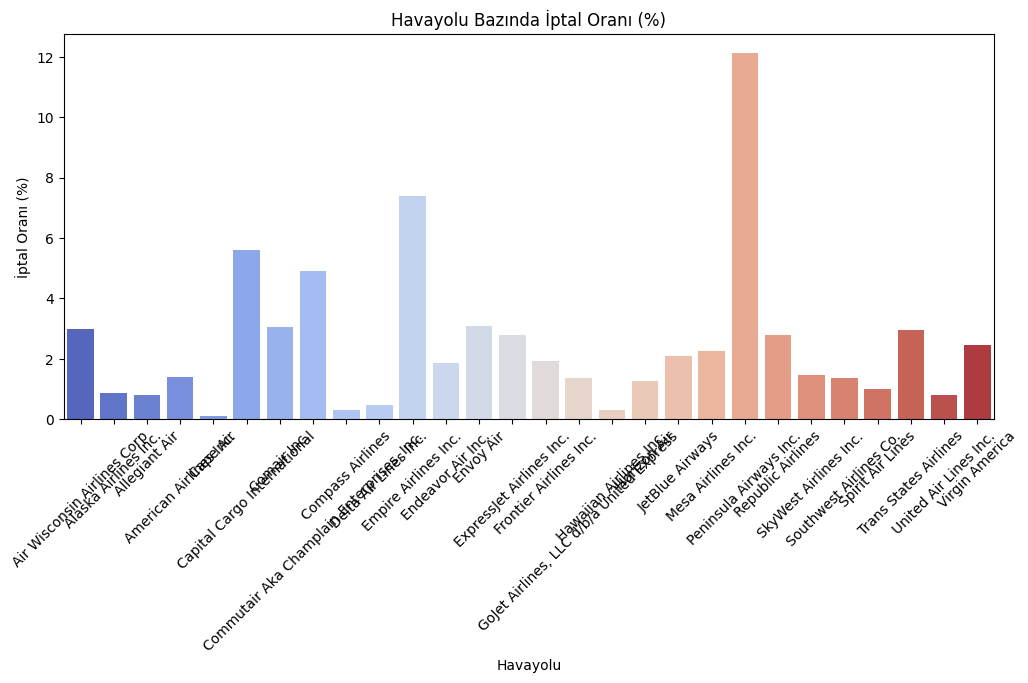

/tmp/ipython-input-2113445448.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=origin_cancel.index, y=origin_cancel.values, palette="Spectral")


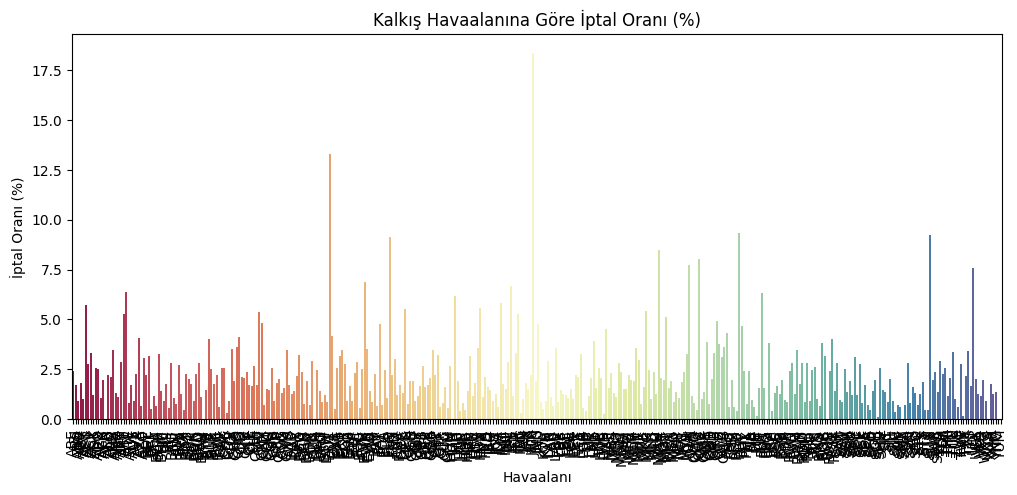

/tmp/ipython-input-2113445448.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dest_cancel.index, y=dest_cancel.values, palette="Spectral_r")


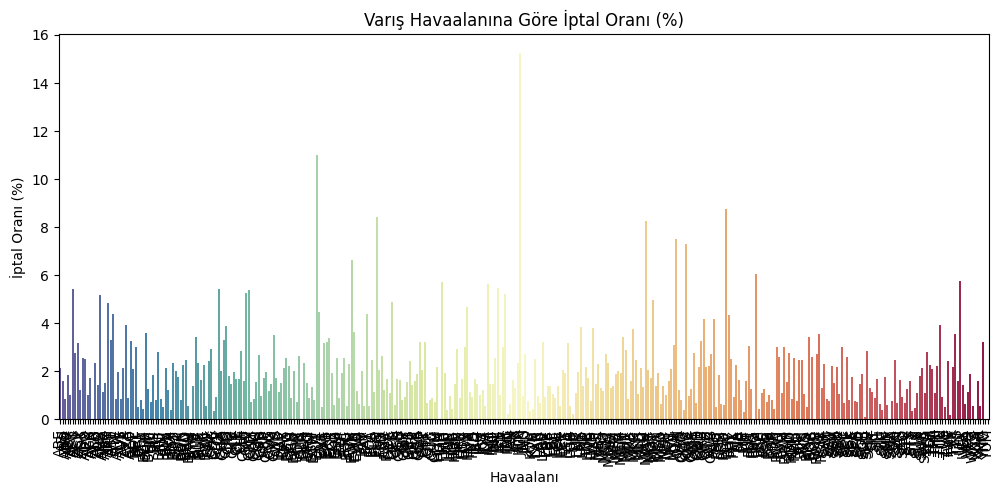

/tmp/ipython-input-2113445448.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist_cancel.index, y=dist_cancel.values, palette="cubehelix")


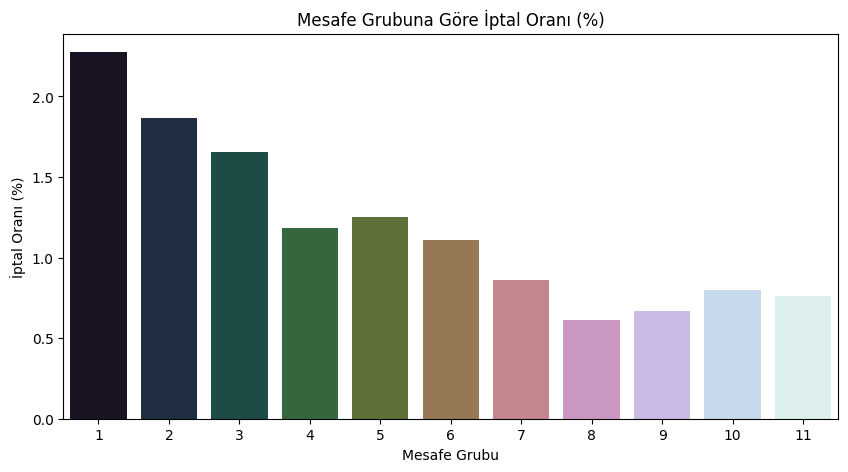

/tmp/ipython-input-2113445448.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dep_delay_cancel.index, y=dep_delay_cancel.values, palette="mako")


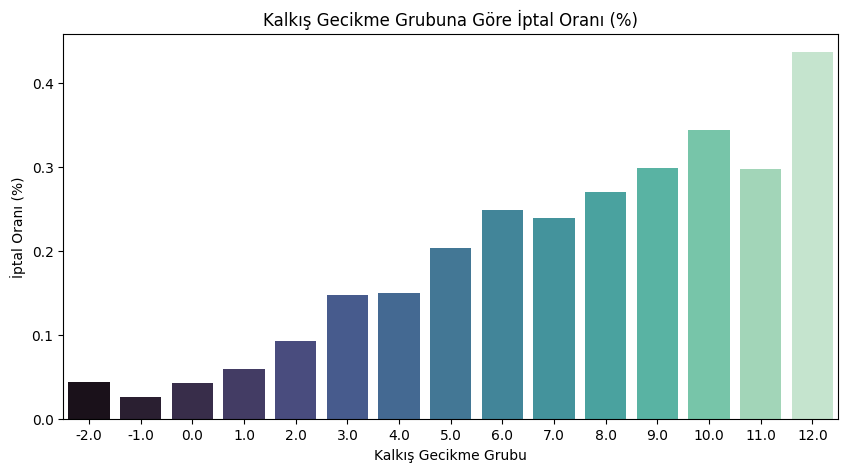

/tmp/ipython-input-2113445448.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=arr_delay_cancel.index, y=arr_delay_cancel.values, palette="rocket")


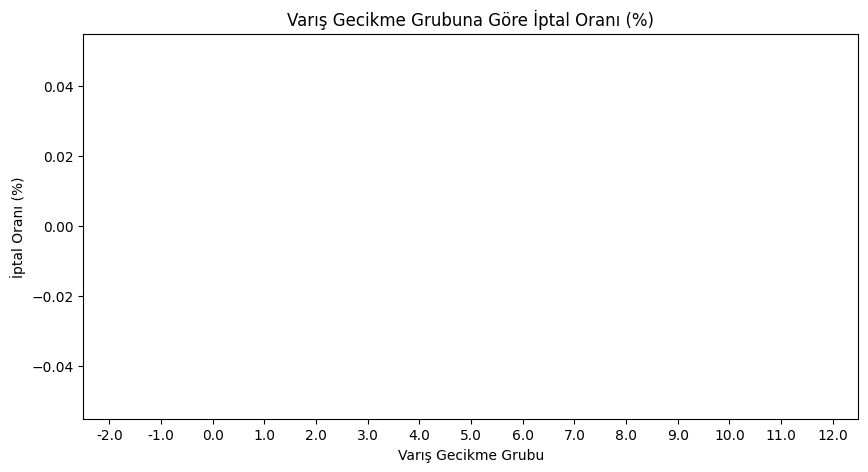

ValueError: cannot reindex on an axis with duplicate labels

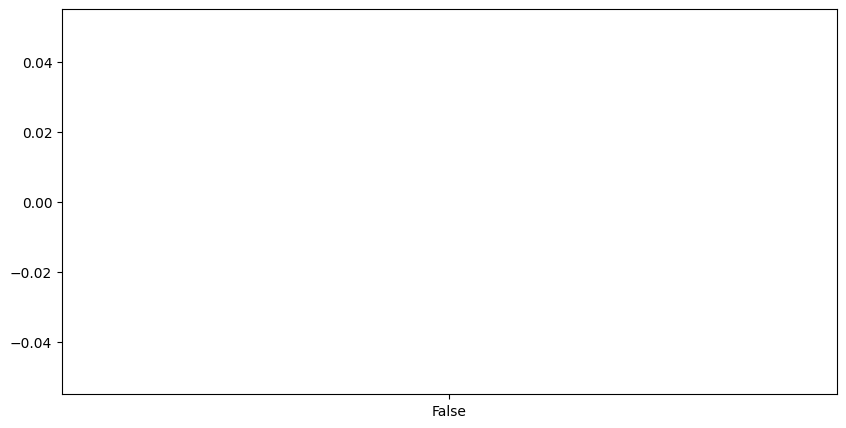

In [ ]:
# --- 1️⃣ Zaman Bazlı Analiz ---
# Aylık iptal sayısı
df=veri
monthly_cancel = df.groupby('Month')['Cancelled'].mean() * 100
plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_cancel.index, y=monthly_cancel.values, marker='o')
plt.title("Aylara Göre İptal Oranı (%)")
plt.xlabel("Ay")
plt.ylabel("İptal Oranı (%)")
plt.show()

# Haftanın günlerine göre iptal oranı
dow_cancel = df.groupby('DayOfWeek')['Cancelled'].mean() * 100
plt.figure(figsize=(8,5))
sns.barplot(x=dow_cancel.index, y=dow_cancel.values, palette="viridis")
plt.title("Haftanın Günlerine Göre İptal Oranı (%)")
plt.xlabel("Gün (1=Monday)")
plt.ylabel("İptal Oranı (%)")
plt.show()

# Yıllara göre iptal oranı
year_cancel = df.groupby('Year')['Cancelled'].mean() * 100
plt.figure(figsize=(8,5))
sns.barplot(x=year_cancel.index, y=year_cancel.values, palette="magma")
plt.title("Yıllara Göre İptal Oranı (%)")
plt.xlabel("Yıl")
plt.ylabel("İptal Oranı (%)")
plt.show()

# --- 2️⃣ Havayolu Bazlı Analiz ---
airline_cancel = df.groupby('Airline')['Cancelled'].mean() * 100
plt.figure(figsize=(12,5))
sns.barplot(x=airline_cancel.index, y=airline_cancel.values, palette="coolwarm")
plt.title("Havayolu Bazında İptal Oranı (%)")
plt.xlabel("Havayolu")
plt.ylabel("İptal Oranı (%)")
plt.xticks(rotation=45)
plt.show()

# --- 3️⃣ Havaalanı / Rota Analizi ---
# Kalkış havaalanına göre iptal oranı
origin_cancel = df.groupby('Origin')['Cancelled'].mean() * 100
plt.figure(figsize=(12,5))
sns.barplot(x=origin_cancel.index, y=origin_cancel.values, palette="Spectral")
plt.title("Kalkış Havaalanına Göre İptal Oranı (%)")
plt.xlabel("Havaalanı")
plt.ylabel("İptal Oranı (%)")
plt.xticks(rotation=90)
plt.show()

# Varış havaalanına göre iptal oranı
dest_cancel = df.groupby('Dest')['Cancelled'].mean() * 100
plt.figure(figsize=(12,5))
sns.barplot(x=dest_cancel.index, y=dest_cancel.values, palette="Spectral_r")
plt.title("Varış Havaalanına Göre İptal Oranı (%)")
plt.xlabel("Havaalanı")
plt.ylabel("İptal Oranı (%)")
plt.xticks(rotation=90)
plt.show()

# DistanceGroup vs iptal oranı
dist_cancel = df.groupby('DistanceGroup')['Cancelled'].mean() * 100
plt.figure(figsize=(10,5))
sns.barplot(x=dist_cancel.index, y=dist_cancel.values, palette="cubehelix")
plt.title("Mesafe Grubuna Göre İptal Oranı (%)")
plt.xlabel("Mesafe Grubu")
plt.ylabel("İptal Oranı (%)")
plt.show()

# --- 4️⃣ Gecikme ve İptal İlişkisi ---
# DepDelayGroups vs iptal oranı
dep_delay_cancel = df.groupby('DepartureDelayGroups')['Cancelled'].mean() * 100
plt.figure(figsize=(10,5))
sns.barplot(x=dep_delay_cancel.index, y=dep_delay_cancel.values, palette="mako")
plt.title("Kalkış Gecikme Grubuna Göre İptal Oranı (%)")
plt.xlabel("Kalkış Gecikme Grubu")
plt.ylabel("İptal Oranı (%)")
plt.show()

# ArrivalDelayGroups vs iptal oranı
arr_delay_cancel = df.groupby('ArrivalDelayGroups')['Cancelled'].mean() * 100
plt.figure(figsize=(10,5))
sns.barplot(x=arr_delay_cancel.index, y=arr_delay_cancel.values, palette="rocket")
plt.title("Varış Gecikme Grubuna Göre İptal Oranı (%)")
plt.xlabel("Varış Gecikme Grubu")
plt.ylabel("İptal Oranı (%)")
plt.show()

# AirTime vs iptal oranı
plt.figure(figsize=(10,5))
sns.boxplot(x='Cancelled', y='AirTime', data=df)
plt.title("İptal ve Havada Geçen Süre (AirTime)")
plt.xlabel("İptal Edildi (0=Hayır, 1=Evet)")
plt.ylabel("Havada Geçen Süre (dakika)")
plt.show()

# --- 5️⃣ Heatmap Örnekleri ---
# Airline × Month iptal oranı
airline_month = df.pivot_table(index='Airline', columns='Month', values='Cancelled', aggfunc='mean') * 100
plt.figure(figsize=(12,6))
sns.heatmap(airline_month, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Havayolu × Ay İptal Oranı (%)")
plt.show()

# Airline × DayOfWeek iptal oranı
airline_dow = df.pivot_table(index='Airline', columns='DayOfWeek', values='Cancelled', aggfunc='mean') * 100
plt.figure(figsize=(12,6))
sns.heatmap(airline_dow, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Havayolu × Haftanın Günü İptal Oranı (%)")
plt.show()